## Contents

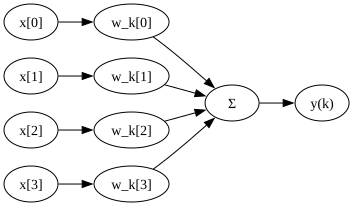

In [1]:
from graphviz import Digraph

g = Digraph(format="svg")
g.attr(rankdir="LR")

# Inputs
for i in range(4):
    g.node(f"x{i}", f"x[{i}]")
    g.node(f"w{i}", f"w_k[{i}]")
    g.edge(f"x{i}", f"w{i}")

# Sum node
g.node("sum", "Σ")
for i in range(4):
    g.edge(f"w{i}", "sum")

g.node("y", "y(k)")
g.edge("sum", "y")

g

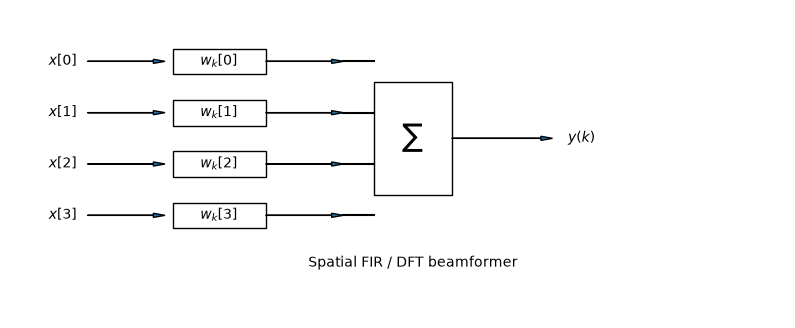

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")

# Input nodes
ys = [5, 4, 3, 2]
for i, y in enumerate(ys):
    ax.text(0.5, y, rf"$x[{i}]$", va="center")
    ax.arrow(1.0, y, 1.0, 0, head_width=0.08, head_length=0.15, length_includes_head=True)

    rect = Rectangle((2.1, y - 0.25), 1.2, 0.5, fill=False)
    ax.add_patch(rect)
    ax.text(2.7, y, rf"$w_k[{i}]$", ha="center", va="center")

    ax.arrow(3.3, y, 1.0, 0, head_width=0.08, head_length=0.15, length_includes_head=True)

# Summer
sum_rect = Rectangle((4.7, 2.4), 1.0, 2.2, fill=False)
ax.add_patch(sum_rect)
ax.text(5.2, 3.5, r"$\sum$", ha="center", va="center", fontsize=16)

for y in ys:
    ax.plot([4.3, 4.7], [y, y], "k-")

# Output
ax.arrow(5.7, 3.5, 1.3, 0, head_width=0.08, head_length=0.15, length_includes_head=True)
ax.text(7.2, 3.5, r"$y(k)$", va="center")

ax.text(5.2, 1.0, "Spatial FIR / DFT beamformer", ha="center")

plt.show()

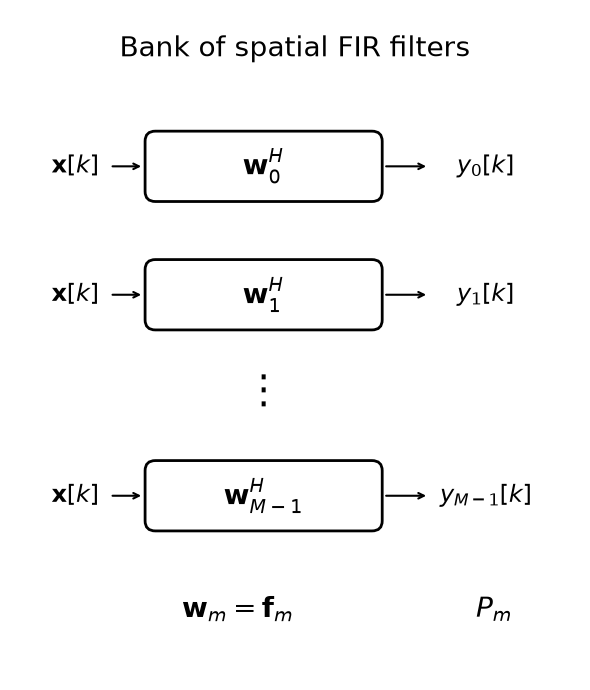

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ------------------------------------------------------------
# Bank of spatial FIR filters
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis("off")

# Title
ax.text(
    5, 11.3,
    "Bank of spatial FIR filters",
    ha="center",
    va="center",
    fontsize=20,
)

# Vertical positions of the displayed filters
y_positions = [9.2, 6.9, 3.3]
indices = [0, 1, "M-1"]

for y, idx in zip(y_positions, indices):

    # Input label
    ax.text(
        1.15, y,
        r"$\mathbf{x}[k]$",
        ha="center",
        va="center",
        fontsize=17,
    )

    # Input arrow
    ax.annotate(
        "",
        xy=(2.35, y),
        xytext=(1.75, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    # Filter block
    block = FancyBboxPatch(
        (2.45, y - 0.55),
        4.0,
        1.1,
        boxstyle="round,pad=0.08,rounding_size=0.18",
        fill=False,
        linewidth=2.0,
    )
    ax.add_patch(block)

    # Filter coefficient
    ax.text(
        4.45, y,
        rf"$\mathbf{{w}}_{{{idx}}}^{{H}}$",
        ha="center",
        va="center",
        fontsize=20,
    )

    # Output arrow
    ax.annotate(
        "",
        xy=(7.35, y),
        xytext=(6.55, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    # Output label
    ax.text(
        8.35, y,
        rf"$y_{{{idx}}}[k]$",
        ha="center",
        va="center",
        fontsize=17,
    )

# Vertical ellipsis
ax.text(
    4.45, 5.15,
    r"$\vdots$",
    ha="center",
    va="center",
    fontsize=28,
)

# Bottom relationship
ax.text(
    4.0, 1.25,
    r"$\mathbf{w}_m=\mathbf{f}_m$",
    ha="center",
    va="center",
    fontsize=20,
)

ax.text(
    8.5, 1.25,
    r"$P_m$",
    ha="center",
    va="center",
    fontsize=20,
)

plt.tight_layout()
plt.show()